In [2]:
# ! pip show nbformat
# !pip install pandas
# !pip3 uninstall plotly
# !pip install --upgrade plotly
# !pip3 install plotly --upgrade

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
import re
import plotly.express as px
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
import math
import scipy.stats as stats
from path_info import path as p

In [4]:
df = pd.read_csv(p.path_to_nutrition_final_dataset)
df.head()

,Unnamed: 0,category,product,name,natural_form,serving_size,calories,total_fat,saturated_fat,cholesterol,...,fat,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,fatty_acids_total_trans,alcohol,ash,caffeine,theobromine,water
0,0,Grains,Cornstarch,Cornstarch,edible,100 g,381,0.1g,NaN,0,...,0.05 g,0.009 g,0.016 g,0.025 g,0.00 mg,0.0 g,0.09 g,0.00 mg,0.00 mg,8.32 g
1,1,Legumes and seeds,Nuts pecans,"Nuts, pecans",edible,100 g,691,72g,6.2g,0,...,71.97 g,6.180 g,40.801 g,21.614 g,0.00 mg,0.0 g,1.49 g,0.00 mg,0.00 mg,3.52 g
2,2,Vegetables,Eggplant raw,"Eggplant, raw",raw,100 g,25,0.2g,NaN,0,...,0.18 g,0.034 g,0.016 g,0.076 g,0.00 mg,0.0 g,0.66 g,0.00 mg,0.00 mg,92.30 g
3,3,Grains,Teff uncooked,"Teff, uncooked",raw,100 g,367,2.4g,0.4g,0,...,2.38 g,0.449 g,0.589 g,1.071 g,0,0,2.37 g,0,0,8.82 g
4,4,Fruits,Sherbet orange,"Sherbet, orange",edible,100 g,144,2g,1.2g,1mg,...,2.00 g,1.160 g,0.530 g,0.080 g,1.00 mg,0.0 g,0.40 g,0.00 mg,0.00 mg,66.10 g


In [5]:
df.drop(columns=['Unnamed: 0'],axis = 0, inplace= True)
df.columns


Index(['category', 'product', 'name', 'natural_form', 'serving_size',
       'calories', 'total_fat', 'saturated_fat', 'cholesterol', 'sodium',
       'choline', 'folate', 'folic_acid', 'niacin', 'pantothenic_acid',
       'riboflavin', 'thiamin', 'vitamin_a', 'vitamin_a_rae', 'carotene_alpha',
       'carotene_beta', 'cryptoxanthin_beta', 'lutein_zeaxanthin', 'lucopene',
       'vitamin_b12', 'vitamin_b6', 'vitamin_c', 'vitamin_d', 'vitamin_e',
       'tocopherol_alpha', 'vitamin_k', 'calcium', 'copper', 'irom',
       'magnesium', 'manganese', 'phosphorous', 'potassium', 'selenium',
       'zink', 'protein', 'alanine', 'arginine', 'aspartic_acid', 'cystine',
       'glutamic_acid', 'glycine', 'histidine', 'hydroxyproline', 'isoleucine',
       'leucine', 'lysine', 'methionine', 'phenylalanine', 'proline', 'serine',
       'threonine', 'tryptophan', 'tyrosine', 'valine', 'carbohydrate',
       'fiber', 'sugars', 'fructose', 'galactose', 'glucose', 'lactose',
       'maltose', 'sucrose

In [6]:
df.head(1)

,category,product,name,natural_form,serving_size,calories,total_fat,saturated_fat,cholesterol,sodium,...,fat,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,fatty_acids_total_trans,alcohol,ash,caffeine,theobromine,water
0,Grains,Cornstarch,Cornstarch,edible,100 g,381,0.1g,NaN,0,9.00 mg,...,0.05 g,0.009 g,0.016 g,0.025 g,0.00 mg,0.0 g,0.09 g,0.00 mg,0.00 mg,8.32 g


In [7]:
df.columns

Index(['category', 'product', 'name', 'natural_form', 'serving_size',
       'calories', 'total_fat', 'saturated_fat', 'cholesterol', 'sodium',
       'choline', 'folate', 'folic_acid', 'niacin', 'pantothenic_acid',
       'riboflavin', 'thiamin', 'vitamin_a', 'vitamin_a_rae', 'carotene_alpha',
       'carotene_beta', 'cryptoxanthin_beta', 'lutein_zeaxanthin', 'lucopene',
       'vitamin_b12', 'vitamin_b6', 'vitamin_c', 'vitamin_d', 'vitamin_e',
       'tocopherol_alpha', 'vitamin_k', 'calcium', 'copper', 'irom',
       'magnesium', 'manganese', 'phosphorous', 'potassium', 'selenium',
       'zink', 'protein', 'alanine', 'arginine', 'aspartic_acid', 'cystine',
       'glutamic_acid', 'glycine', 'histidine', 'hydroxyproline', 'isoleucine',
       'leucine', 'lysine', 'methionine', 'phenylalanine', 'proline', 'serine',
       'threonine', 'tryptophan', 'tyrosine', 'valine', 'carbohydrate',
       'fiber', 'sugars', 'fructose', 'galactose', 'glucose', 'lactose',
       'maltose', 'sucrose

In [8]:
Minerals = df[['product','calcium','copper','irom','magnesium','manganese','phosphorous','potassium','selenium','zink']]
Minerals.head()

,product,calcium,copper,irom,magnesium,manganese,phosphorous,potassium,selenium,zink
0,Cornstarch,2.00 mg,0.050 mg,0.47 mg,3.00 mg,0.053 mg,13.00 mg,3.00 mg,2.8 mcg,0.06 mg
1,Nuts pecans,70.00 mg,1.200 mg,2.53 mg,121.00 mg,4.500 mg,277.00 mg,410.00 mg,3.8 mcg,4.53 mg
2,Eggplant raw,9.00 mg,0.081 mg,0.23 mg,14.00 mg,0.232 mg,24.00 mg,229.00 mg,0.3 mcg,0.16 mg
3,Teff uncooked,180.00 mg,0.810 mg,7.63 mg,184.00 mg,9.240 mg,429.00 mg,427.00 mg,4.4 mcg,3.63 mg
4,Sherbet orange,54.00 mg,0.028 mg,0.14 mg,8.00 mg,0.011 mg,40.00 mg,96.00 mg,1.5 mcg,0.48 mg


In [9]:
def to_grams(value):
    value = str(value).lower()
    if 'mg' in value:
        return float(value.replace('mg', '').strip()) / 1000
    elif 'mcg' in value:
        return float(value.replace('mcg', '').strip()) / 1000000
    else:
        return float(value)
columns_to_convert = ['calcium', 'copper', 'irom', 'magnesium', 'manganese', 'phosphorous', 'potassium', 'selenium', 'zink']
for column in columns_to_convert:
    Minerals[column] = Minerals[column].apply(to_grams)
Minerals.head()
Minerals.dtypes

C:\Users\vedang\AppData\Local\Temp\1\ipykernel_31692\2323003276.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Minerals[column] = Minerals[column].apply(to_grams)


product         object
calcium        float64
copper         float64
irom           float64
magnesium      float64
manganese      float64
phosphorous    float64
potassium      float64
selenium       float64
zink           float64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8789 entries, 0 to 8788
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   category                     8789 non-null   object
 1   product                      8789 non-null   object
 2   name                         8789 non-null   object
 3   natural_form                 8789 non-null   object
 4   serving_size                 8789 non-null   object
 5   calories                     8789 non-null   int64 
 6   total_fat                    8789 non-null   object
 7   saturated_fat                7199 non-null   object
 8   cholesterol                  8789 non-null   object
 9   sodium                       8789 non-null   object
 10  choline                      8789 non-null   object
 11  folate                       8789 non-null   object
 12  folic_acid                   8789 non-null   object
 13  niacin                       8789


# Analyze the distribution of key nutritional components


In [11]:
nutrients = df[['category', 'product', 'serving_size', 'calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']]
nutrients.head(-5)

,category,product,serving_size,calories,protein,total_fat,carbohydrate,fiber,sugars
0,Grains,Cornstarch,100 g,381,0.26 g,0.1g,91.27 g,0.9 g,0.00 g
1,Legumes and seeds,Nuts pecans,100 g,691,9.17 g,72g,13.86 g,9.6 g,3.97 g
2,Vegetables,Eggplant raw,100 g,25,0.98 g,0.2g,5.88 g,3.0 g,3.53 g
3,Grains,Teff uncooked,100 g,367,13.30 g,2.4g,73.13 g,8.0 g,1.84 g
4,Fruits,Sherbet orange,100 g,144,1.10 g,2g,30.40 g,1.3 g,24.32 g
...,...,...,...,...,...,...,...,...,...
8779,Red Meat,"Beef braised cooked all grades trimmed to 1/8""...",100 g,289,28.82 g,18g,0.00 g,0.0 g,0.00 g
8780,Red Meat,"Beef raw select trimmed to 1/8"" fat separable ...",100 g,148,22.55 g,6.4g,0.00 g,0.0 g,0.00 g
8781,Red Meat,"Beef raw choice trimmed to 1/8"" fat separable ...",100 g,161,21.62 g,8.3g,0.00 g,0.0 g,0.00 g
8782,Oil,Oil uses similar to 95 degree hard butter conf...,100 g,884,0.00 g,100g,0.00 g,0.0 g,0.00 g


In [12]:
columns_to_convert = ['serving_size' ,'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']

for column in columns_to_convert:
    nutrients[column] = pd.to_numeric(nutrients[column].apply(lambda x: float(re.sub(r'\s*g$', '', x)) if isinstance(x, str) and re.search(r'\s*g$', x) else x))
    
nutrients.head(1)  
# nutrients.to_csv("nutrients.csv", index = False)     


C:\Users\vedang\AppData\Local\Temp\1\ipykernel_31692\1043148987.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nutrients[column] = pd.to_numeric(nutrients[column].apply(lambda x: float(re.sub(r'\s*g$', '', x)) if isinstance(x, str) and re.search(r'\s*g$', x) else x))


,category,product,serving_size,calories,protein,total_fat,carbohydrate,fiber,sugars
0,Grains,Cornstarch,100.0,381,0.26,0.1,91.27,0.9,0.0


# 

In [13]:
# nutrients['calories per 100 gm of protien'] =
(nutrients['calories']/nutrients['protein'])
# nutrients.head()

0       1465.384615
1         75.354417
2         25.510204
3         27.593985
4        130.909091
           ...     
8784       5.330490
8785       6.961811
8786      16.547192
8787       5.177578
8788       5.177578
Length: 8789, dtype: float64

In [14]:
nutrients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8789 entries, 0 to 8788
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   category      8789 non-null   object 
 1   product       8789 non-null   object 
 2   serving_size  8789 non-null   float64
 3   calories      8789 non-null   int64  
 4   protein       8789 non-null   float64
 5   total_fat     8789 non-null   float64
 6   carbohydrate  8789 non-null   float64
 7   fiber         8789 non-null   float64
 8   sugars        8789 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 618.1+ KB


In [15]:
nutrients.isna().sum()

category        0
product         0
serving_size    0
calories        0
protein         0
total_fat       0
carbohydrate    0
fiber           0
sugars          0
dtype: int64

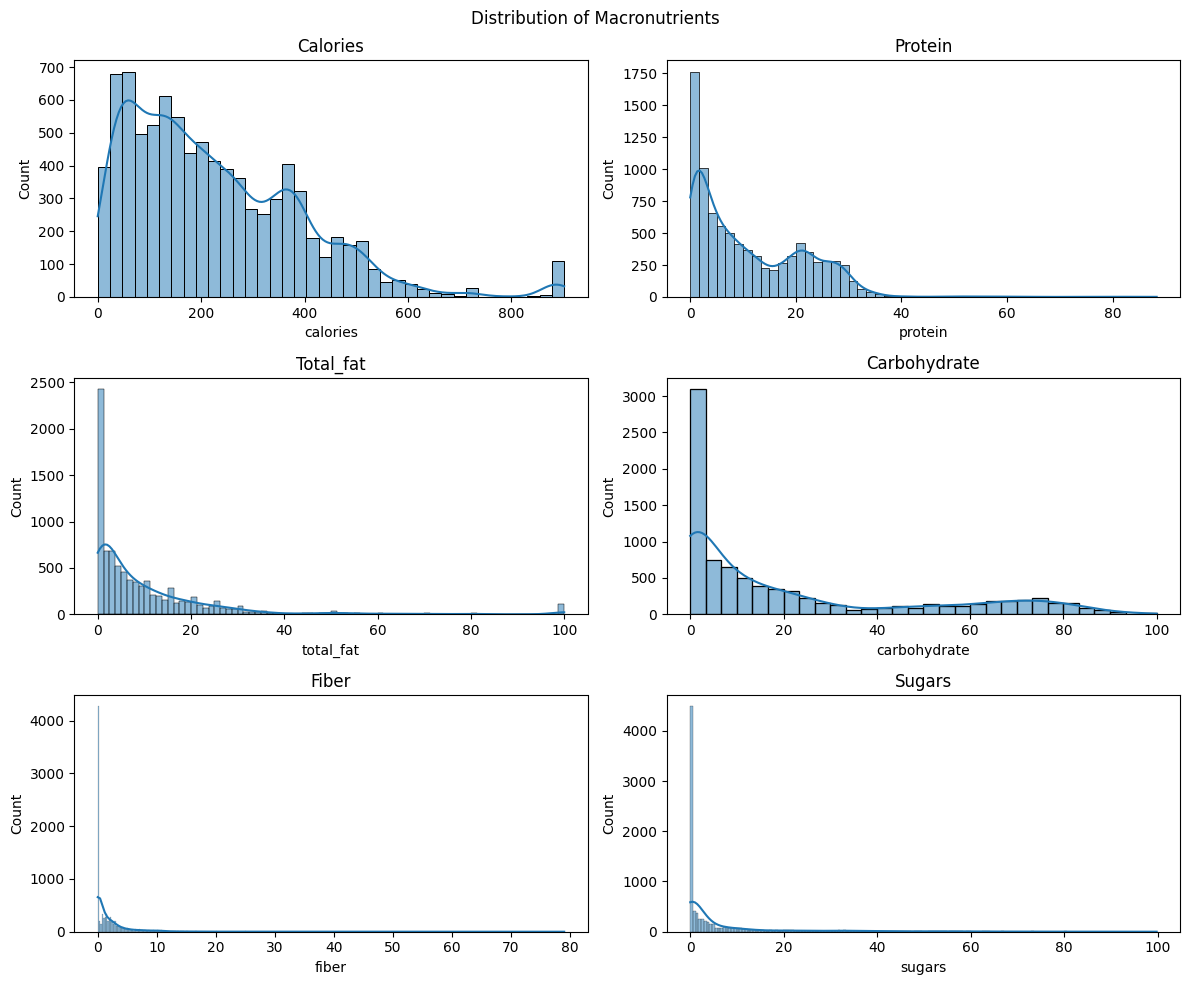

In [16]:
macronutrients = nutrients[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
fig.suptitle('Distribution of Macronutrients')

for i, nutrient in enumerate(macronutrients):
    sns.histplot(nutrients[nutrient], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(nutrient.capitalize())

plt.tight_layout()
plt.show()


In [17]:
nutrients['category'].unique()

array(['Grains', 'Legumes and seeds', 'Vegetables', 'Fruits', 'Red Meat',
       'Dairy', 'Sauce', 'Snacks', 'Poultry', 'Condiments', 'Eggs',
       'Miscellaneous Ingredients', 'Seafood', 'Oil', 'Beverages'],
      dtype=object)

# Correlation between Nutrients and Minerals

In [18]:
correlation = pd.merge(nutrients, Minerals, on='product', how='left')
correlation.head(-5)

,category,product,serving_size,calories,protein,total_fat,carbohydrate,fiber,sugars,calcium,copper,irom,magnesium,manganese,phosphorous,potassium,selenium,zink
0,Grains,Cornstarch,100.0,381,0.26,0.1,91.27,0.9,0.00,0.002,0.000050,0.00047,0.003,0.000053,0.013,0.003,2.800000e-06,0.00006
1,Legumes and seeds,Nuts pecans,100.0,691,9.17,72.0,13.86,9.6,3.97,0.070,0.001200,0.00253,0.121,0.004500,0.277,0.410,3.800000e-06,0.00453
2,Vegetables,Eggplant raw,100.0,25,0.98,0.2,5.88,3.0,3.53,0.009,0.000081,0.00023,0.014,0.000232,0.024,0.229,3.000000e-07,0.00016
3,Grains,Teff uncooked,100.0,367,13.30,2.4,73.13,8.0,1.84,0.180,0.000810,0.00763,0.184,0.009240,0.429,0.427,4.400000e-06,0.00363
4,Fruits,Sherbet orange,100.0,144,1.10,2.0,30.40,1.3,24.32,0.054,0.000028,0.00014,0.008,0.000011,0.040,0.096,1.500000e-06,0.00048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8779,Red Meat,"Beef braised cooked all grades trimmed to 1/8""...",100.0,289,28.82,18.0,0.00,0.0,0.00,0.016,0.000100,0.00243,0.019,0.000010,0.175,0.232,2.710000e-05,0.00669
8780,Red Meat,"Beef raw select trimmed to 1/8"" fat separable ...",100.0,148,22.55,6.4,0.00,0.0,0.00,0.005,0.000084,0.00180,0.023,0.000082,0.160,0.297,2.700000e-05,0.00572
8781,Red Meat,"Beef raw choice trimmed to 1/8"" fat separable ...",100.0,161,21.62,8.3,0.00,0.0,0.00,0.007,0.000071,0.00204,0.022,0.000071,0.153,0.262,2.750000e-05,0.00563
8782,Oil,Oil uses similar to 95 degree hard butter conf...,100.0,884,0.00,100.0,0.00,0.0,0.00,0.001,0.000000,0.00015,0.000,0.000000,0.000,0.001,0.000000e+00,0.00008


In [19]:
# Check to identify if duplicate values exist
correlation['product'].value_counts()[correlation['product'].value_counts()>1].sum()

np.int64(0)

# Observation 
duplicate values do not exist in product column

In [20]:
corr_matrix = correlation[['calories','protein','total_fat', 'carbohydrate', 'fiber','sugars', 'calcium','copper','irom','magnesium','manganese','phosphorous','potassium','selenium','zink']].corr()
corr_matrix

,calories,protein,total_fat,carbohydrate,fiber,sugars,calcium,copper,irom,magnesium,manganese,phosphorous,potassium,selenium,zink
calories,1.000000,0.112888,0.806574,0.492915,0.202084,0.315696,0.124456,0.102742,0.195025,0.262749,0.037255,0.200676,0.081798,0.061379,0.113362
protein,0.112888,1.000000,0.062268,-0.303971,-0.073940,-0.269118,0.047325,0.152919,0.129556,0.217898,0.034831,0.443580,0.247964,0.394546,0.423621
total_fat,0.806574,0.062268,1.000000,-0.048740,-0.023065,-0.000315,0.016747,0.048087,-0.036208,0.082391,0.001276,0.074200,-0.036413,0.041510,0.031533
carbohydrate,0.492915,-0.303971,-0.048740,1.000000,0.455886,0.616656,0.188224,0.063419,0.342912,0.283711,0.055458,0.074014,0.117700,-0.117244,-0.016911
fiber,0.202084,-0.073940,-0.023065,0.455886,1.000000,0.107279,0.234415,0.186073,0.381205,0.540410,0.102780,0.160587,0.326475,-0.033551,0.082555
sugars,0.315696,-0.269118,-0.000315,0.616656,0.107279,1.000000,0.124171,-0.005189,0.110971,0.040583,0.010016,-0.052985,-0.005961,-0.130163,-0.031463
calcium,0.124456,0.047325,0.016747,0.188224,0.234415,0.124171,1.000000,0.083369,0.351724,0.310880,0.067743,0.566595,0.251893,0.011666,0.142048
copper,0.102742,0.152919,0.048087,0.063419,0.186073,-0.005189,0.083369,1.000000,0.182379,0.338116,0.167562,0.215385,0.201827,0.125273,0.262852
irom,0.195025,0.129556,-0.036208,0.342912,0.381205,0.110971,0.351724,0.182379,1.000000,0.399753,0.093274,0.222629,0.230604,0.066216,0.382486
magnesium,0.262749,0.217898,0.082391,0.283711,0.540410,0.040583,0.310880,0.338116,0.399753,1.000000,0.175457,0.437532,0.505331,0.135740,0.261569


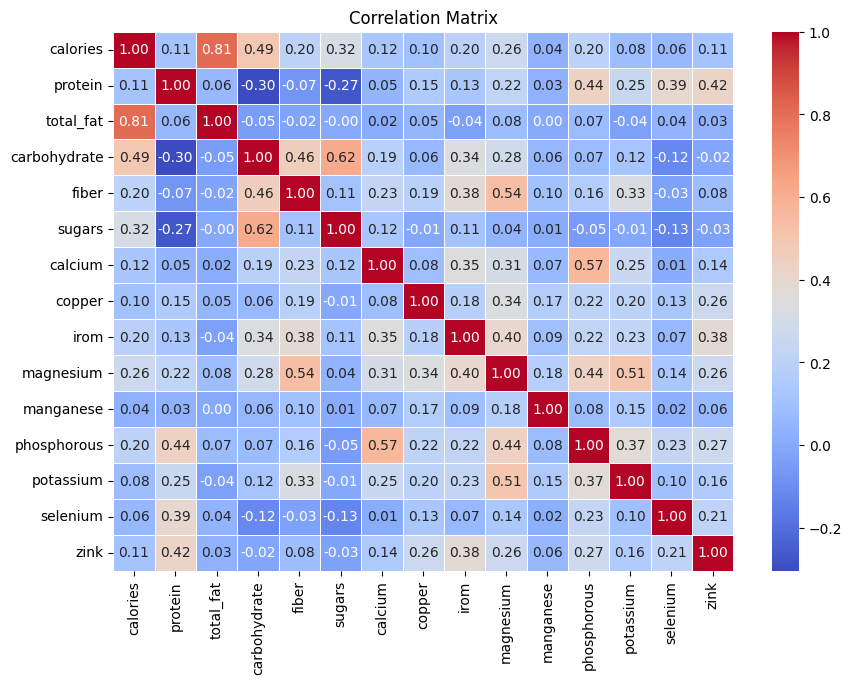

In [21]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

# Observation
1. The correlation between calories and total_fat is high
2. The correlation betweem sugars and carbohyrates is high
3. The correlation betweem carbohrdrate and protein is low
4. The correlation betweem sugars and protein is low







C:\Users\vedang\AppData\Local\Temp\1\ipykernel_31692\210122905.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(nutrients[data], labels=data)


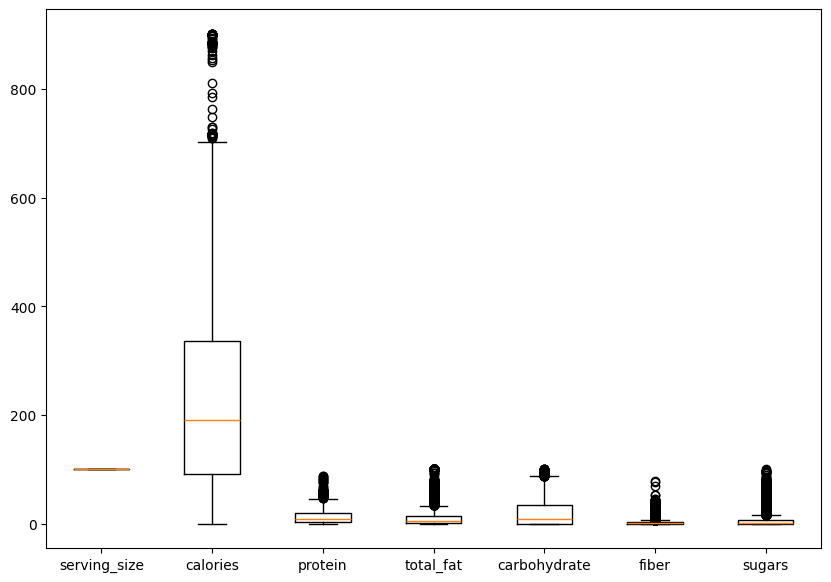

In [22]:
# nutrients.head()
fig = plt.figure(figsize=(10,7))
data = nutrients.columns[2:]    

plt.boxplot(nutrients[data], labels=data)
plt.show()
    

In [23]:
nutrients.head()

,category,product,serving_size,calories,protein,total_fat,carbohydrate,fiber,sugars
0,Grains,Cornstarch,100.0,381,0.26,0.1,91.27,0.9,0.00
1,Legumes and seeds,Nuts pecans,100.0,691,9.17,72.0,13.86,9.6,3.97
2,Vegetables,Eggplant raw,100.0,25,0.98,0.2,5.88,3.0,3.53
3,Grains,Teff uncooked,100.0,367,13.30,2.4,73.13,8.0,1.84
4,Fruits,Sherbet orange,100.0,144,1.10,2.0,30.40,1.3,24.32


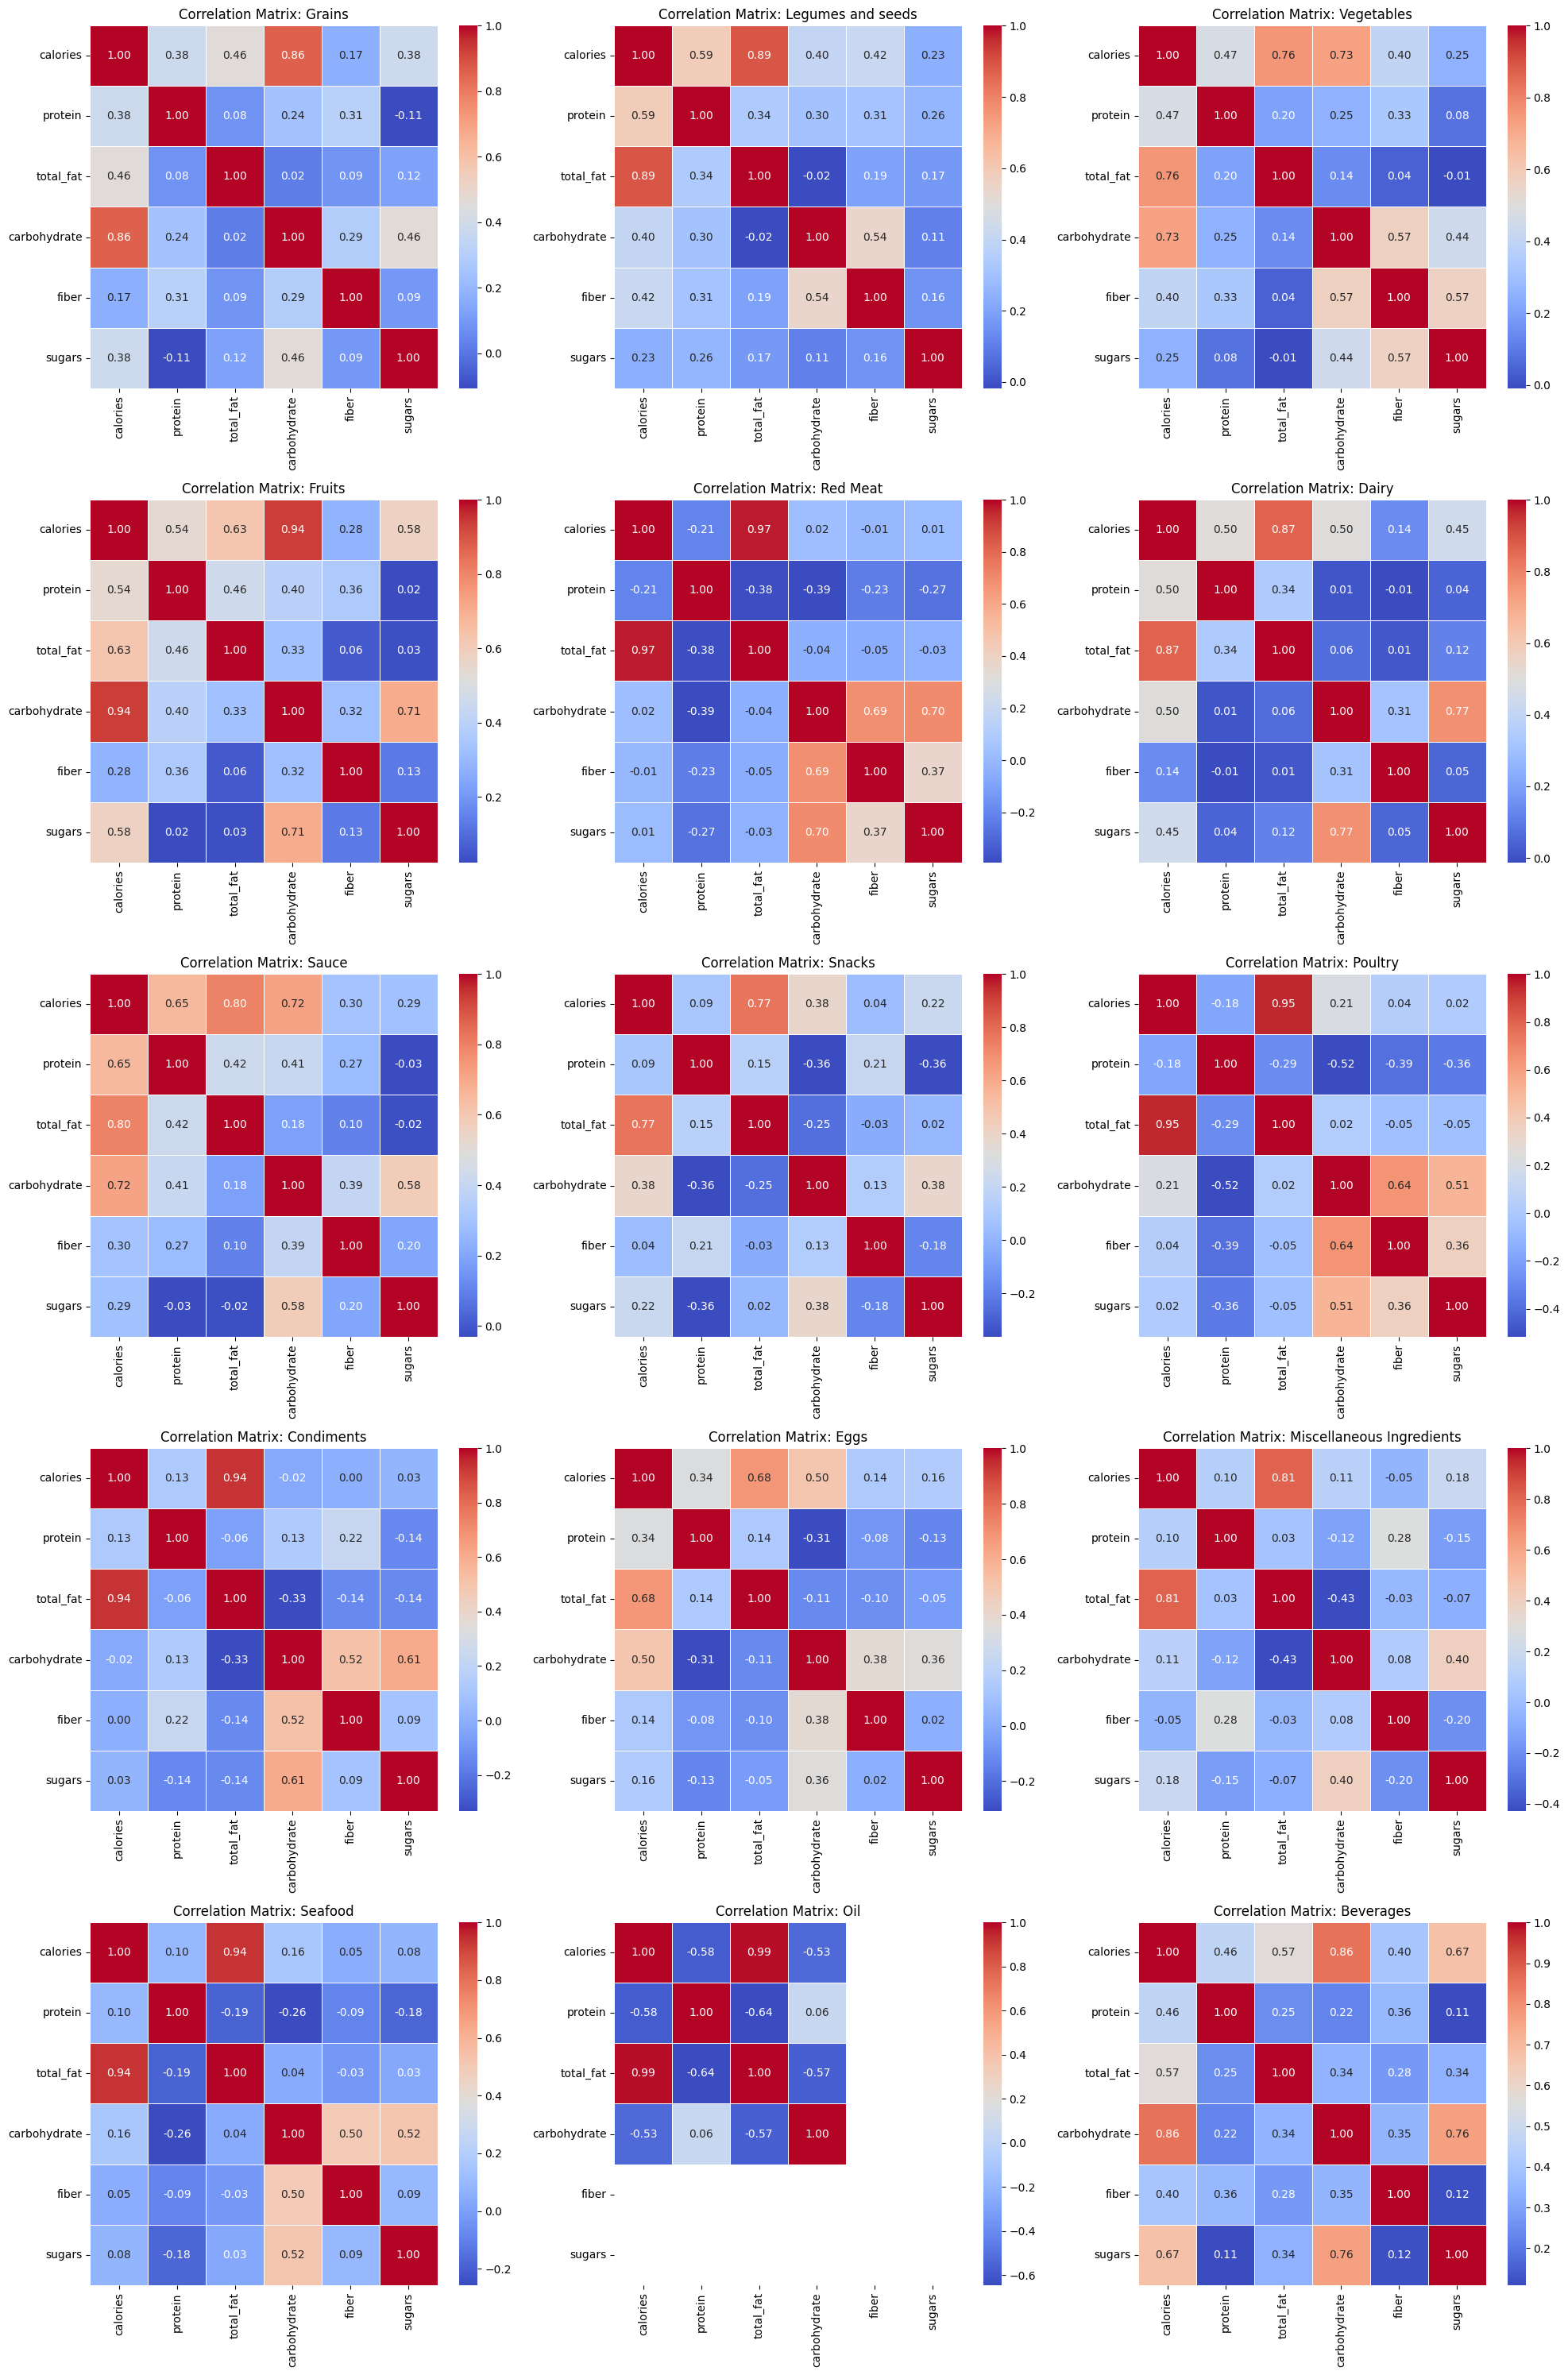

In [24]:
category_list = nutrients['category'].unique().tolist()
rows = math.ceil(len(category_list) / 3)
fig, axs = plt.subplots(rows, 3, figsize=(20, rows * 6))

# Flatten the axes array for easier indexing
axs = axs.flatten()

# Loop through categories and plot heatmaps
for idx, i in enumerate(category_list):
    # Filter data for the current category
    frame = nutrients[nutrients["category"] == i][['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']]
    
    # Reset index
    frame = frame.reset_index(drop=True)
    
    # Compute the correlation matrix
    corr_matrix = frame.corr()
    
    # Plot the heatmap on the corresponding subplot
    sns.heatmap(corr_matrix,
                annot=True,
                cmap='coolwarm',
                fmt=".2f",
                linewidths=.5,
                ax=axs[idx])
    
    # Set title for this subplot
    axs[idx].set_title(f'Correlation Matrix: {i}')
plt.tight_layout()

# Show the plot
plt.show()

# need to add in the observations

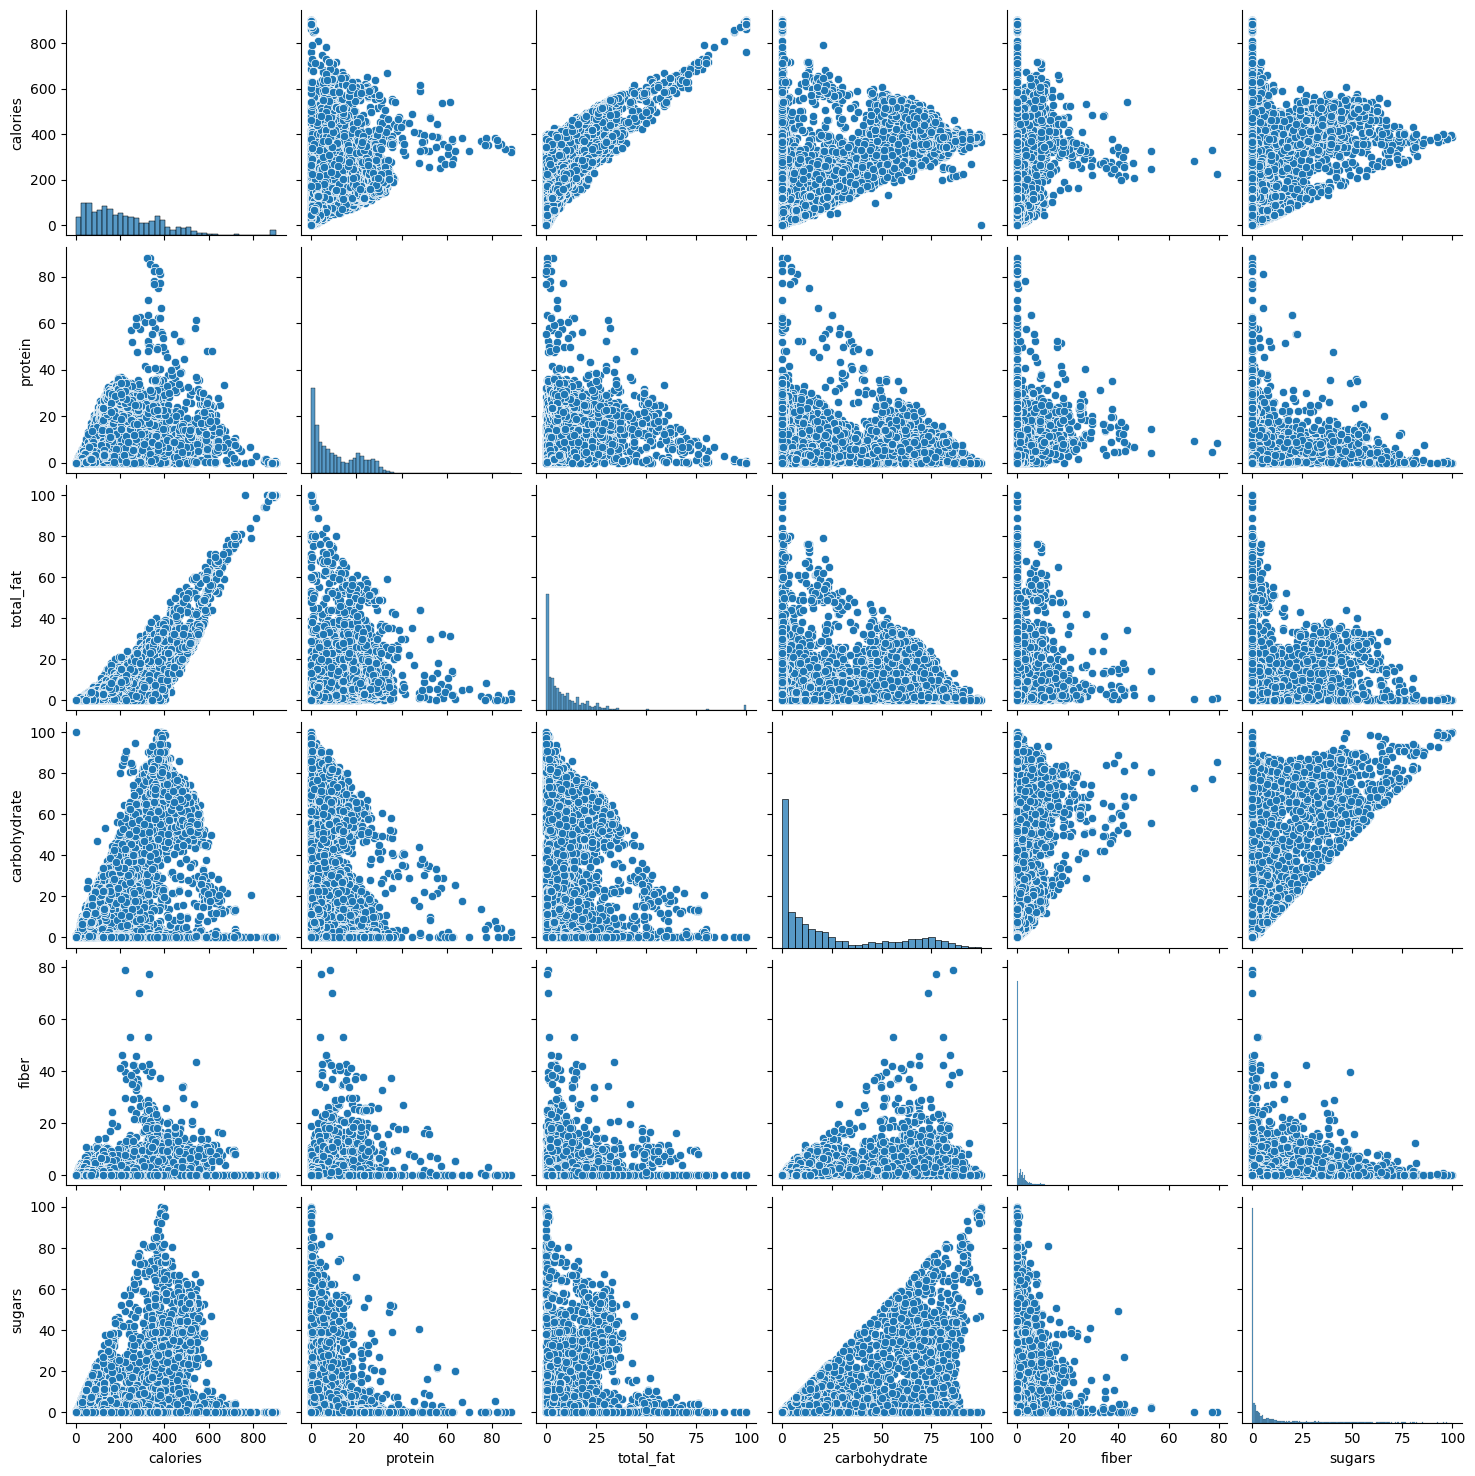

In [25]:
sns.pairplot(nutrients[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']])

In [26]:
x_axis = nutrients['category'].unique().tolist()
y_axis = nutrients[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']]

avg = pd.DataFrame(nutrients.groupby('category')[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']].mean())
avg.reset_index(inplace=True)
avg.drop('calories',axis=1, inplace=True)
avg.head()

,category,protein,total_fat,carbohydrate,fiber,sugars
0,Beverages,2.382903,1.164020,18.125782,0.645161,11.106725
1,Condiments,5.874211,17.859649,16.961111,2.159357,5.545439
2,Dairy,8.476092,10.955882,17.694139,0.449370,10.940315
3,Eggs,10.662305,10.432422,28.946680,1.715625,4.553164
4,Fruits,1.329153,1.493651,25.479365,1.948325,13.915873


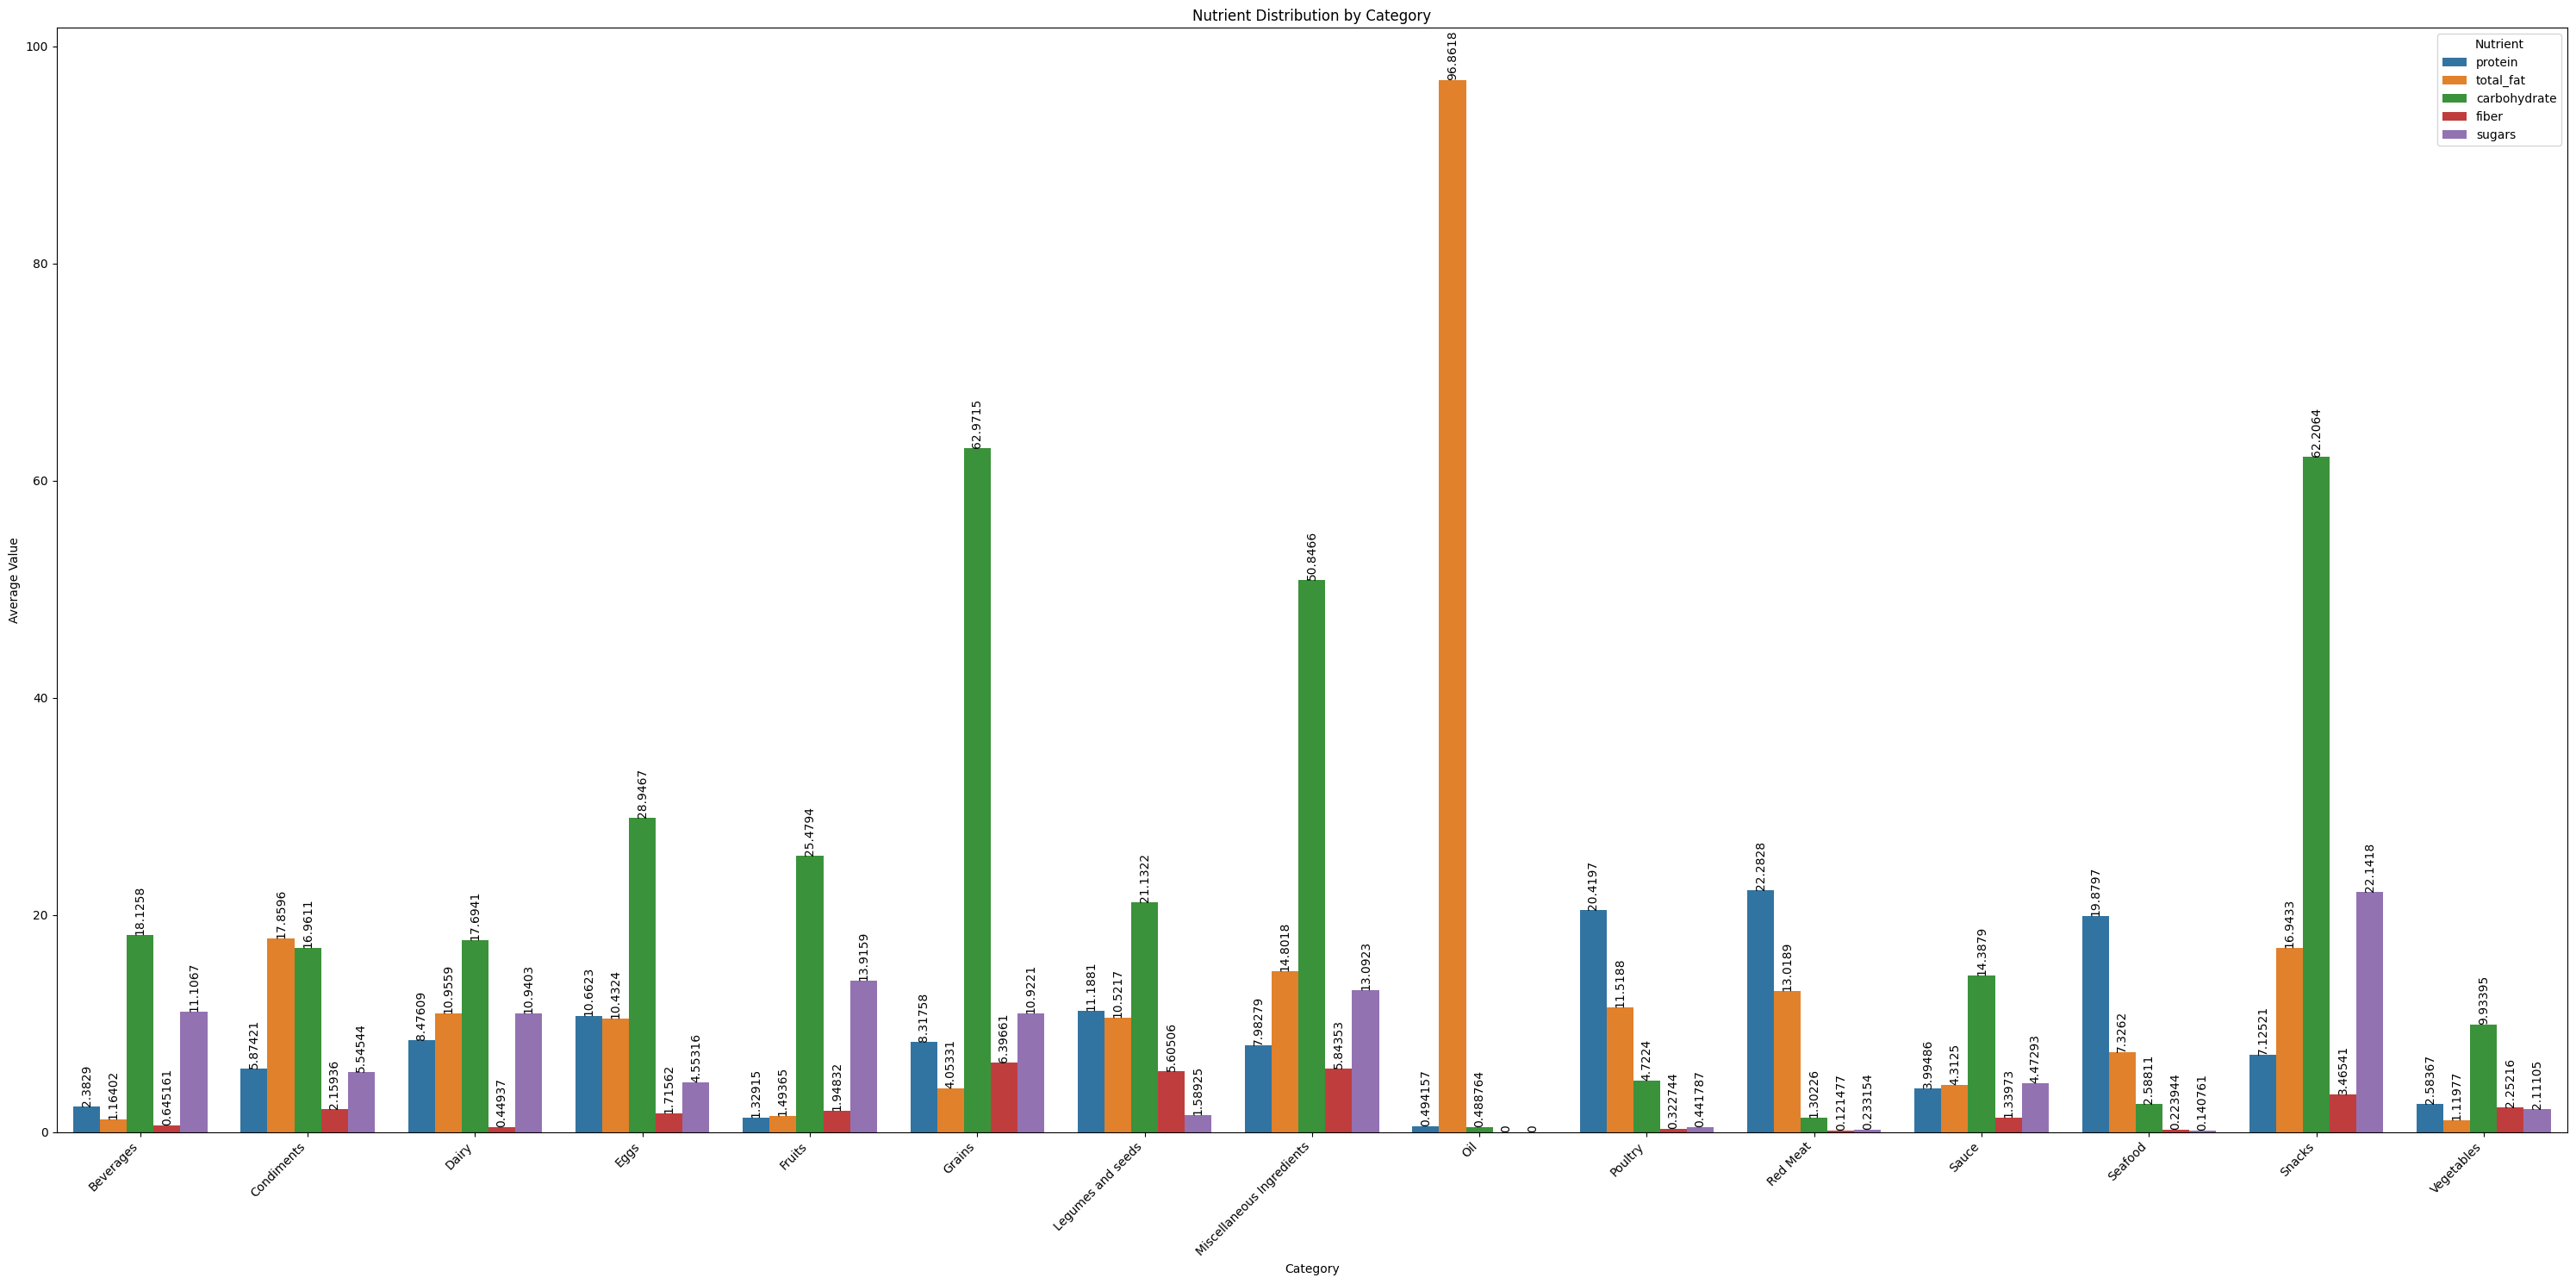

In [27]:
long_nutrients = pd.melt(
    avg,
    id_vars='category',
    value_vars=['protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars'],
    var_name='Nutrient',
    value_name='Value'
)

# Plot using Seaborn
plt.figure(figsize=(30, 15))
ax = sns.barplot(data=long_nutrients, x='category', y='Value', hue='Nutrient', estimator='mean')
for container in ax.containers:
    ax.bar_label(container,rotation=90)
# Add labels and title
plt.title('Nutrient Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Average Value')
plt.legend(title='Nutrient')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [28]:
nutrients.head()

,category,product,serving_size,calories,protein,total_fat,carbohydrate,fiber,sugars
0,Grains,Cornstarch,100.0,381,0.26,0.1,91.27,0.9,0.00
1,Legumes and seeds,Nuts pecans,100.0,691,9.17,72.0,13.86,9.6,3.97
2,Vegetables,Eggplant raw,100.0,25,0.98,0.2,5.88,3.0,3.53
3,Grains,Teff uncooked,100.0,367,13.30,2.4,73.13,8.0,1.84
4,Fruits,Sherbet orange,100.0,144,1.10,2.0,30.40,1.3,24.32


In [29]:
nutrients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8789 entries, 0 to 8788
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   category      8789 non-null   object 
 1   product       8789 non-null   object 
 2   serving_size  8789 non-null   float64
 3   calories      8789 non-null   int64  
 4   protein       8789 non-null   float64
 5   total_fat     8789 non-null   float64
 6   carbohydrate  8789 non-null   float64
 7   fiber         8789 non-null   float64
 8   sugars        8789 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 618.1+ KB


In [30]:
nutrients.isnull().sum()

category        0
product         0
serving_size    0
calories        0
protein         0
total_fat       0
carbohydrate    0
fiber           0
sugars          0
dtype: int64

In [31]:
nutrients.isna().sum()

category        0
product         0
serving_size    0
calories        0
protein         0
total_fat       0
carbohydrate    0
fiber           0
sugars          0
dtype: int64

In [32]:
nutrients.dropna(axis = 0, inplace=True)
nutrients.head()

C:\Users\vedang\AppData\Local\Temp\1\ipykernel_31692\2524856654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nutrients.dropna(axis = 0, inplace=True)


,category,product,serving_size,calories,protein,total_fat,carbohydrate,fiber,sugars
0,Grains,Cornstarch,100.0,381,0.26,0.1,91.27,0.9,0.00
1,Legumes and seeds,Nuts pecans,100.0,691,9.17,72.0,13.86,9.6,3.97
2,Vegetables,Eggplant raw,100.0,25,0.98,0.2,5.88,3.0,3.53
3,Grains,Teff uncooked,100.0,367,13.30,2.4,73.13,8.0,1.84
4,Fruits,Sherbet orange,100.0,144,1.10,2.0,30.40,1.3,24.32


In [33]:
nutrients['product'].unique()

array(['Cornstarch', 'Nuts pecans', 'Eggplant raw', ...,
       'Lamb raw separable lean and fat composite of trimmed retail cuts frozen imported New Zealand',
       'Beef raw all grades trimmed to 0" fat separable lean only boneless eye of round roast round',
       'Beef raw all grades trimmed to 0" fat separable lean only boneless eye of round steak round'],
      shape=(8789,), dtype=object)

In [34]:
print((nutrients['product'].groupby(nutrients['product'])).value_counts())

product                                                                     product                                                                   
ANDREA'S Gluten Free Soft Dinner Roll                                       ANDREA'S Gluten Free Soft Dinner Roll                                         1
APPLEBEE'S 9 oz house sirloin steak                                         APPLEBEE'S 9 oz house sirloin steak                                           1
APPLEBEE'S Double Crunch Shrimp                                             APPLEBEE'S Double Crunch Shrimp                                               1
APPLEBEE'S chicken tenders platter                                          APPLEBEE'S chicken tenders platter                                            1
APPLEBEE'S chili                                                            APPLEBEE'S chili                                                              1
                                                                     

In [35]:
(nutrients == 0).sum(axis=0)

category           0
product            0
serving_size       0
calories          39
protein          358
total_fat        451
carbohydrate    2158
fiber           4053
sugars          3966
dtype: int64

In [36]:
correlation_nutrients = nutrients[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']]
correlation_nutrients.head()

,calories,protein,total_fat,carbohydrate,fiber,sugars
0,381,0.26,0.1,91.27,0.9,0.00
1,691,9.17,72.0,13.86,9.6,3.97
2,25,0.98,0.2,5.88,3.0,3.53
3,367,13.30,2.4,73.13,8.0,1.84
4,144,1.10,2.0,30.40,1.3,24.32


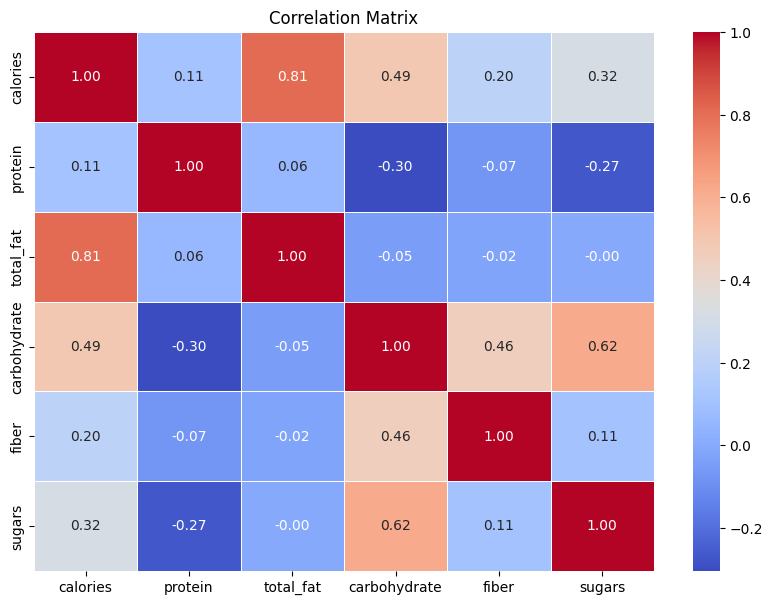

In [37]:
plt.figure(figsize=(10, 7))
sns.heatmap(nutrients[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [38]:
cov_matrix = (nutrients[['calories', 'protein', 'total_fat', 'carbohydrate', 'fiber', 'sugars']]).cov()
print(cov_matrix)

                  calories     protein    total_fat  carbohydrate       fiber  \
calories      28853.099536  201.927429  2167.198003   2282.935012  146.545280   
protein         201.927429  110.893571    10.372262    -87.279328   -3.324122   
total_fat      2167.198003   10.372262   250.216953    -21.021635   -1.557631   
carbohydrate   2282.935012  -87.279328   -21.021635    743.449005   53.067229   
fiber           146.545280   -3.324122    -1.557631     53.067229   18.225907   
sugars          735.671760  -38.878912    -0.068420    230.668172    6.283163   

                  sugars  
calories      735.671760  
protein       -38.878912  
total_fat      -0.068420  
carbohydrate  230.668172  
fiber           6.283163  
sugars        188.207950  


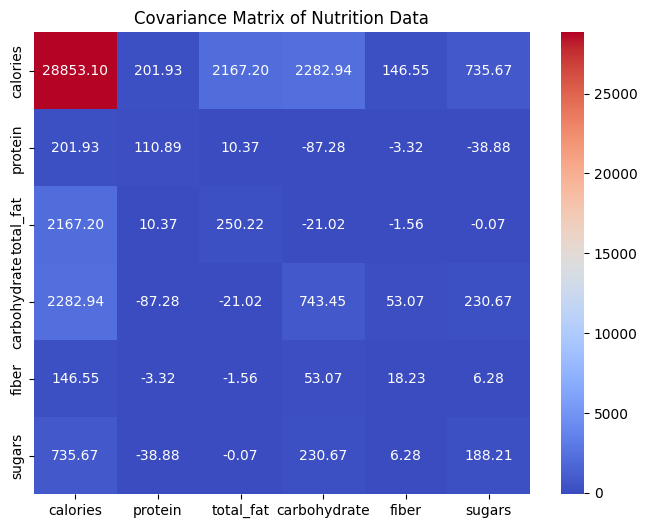

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Covariance Matrix of Nutrition Data')
plt.show()